In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


In [4]:
IMAGE_PATH = '../images/P0006.png'

In [8]:
def count_and_classify_vehicles(image_path):
    # Carrega a imagem
    img = cv2.imread(image_path)
    
    if img is None:
        print(f"ERRO: Nao foi possivel carregar a imagem em {image_path}")
        return

    print(f"INFO: Imagem {image_path} carregada com sucesso.")

    # Converte a imagem colorida para escala de cinza, 
    # pois a limiarizacao de Otsu opera em imagens de canal unico
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    print("INFO: Imagem convertida para escala de cinza.")

    # Aplica a limiarizacao de Otsu
    # cv2.THRESH_BINARY garante que pixels acima do limiar sejam 255 e abaixo sejam 0
    # cv2.THRESH_OTSU calcula automaticamente o limiar ideal
    ret, otsu_thresholded_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print(f"INFO: Limiar de Otsu calculado: {ret}")
    print("INFO: Imagem limiarizada com o metodo de Otsu.")

    # --- Aplica operacoes morfologicas ---
    # Define um elemento estruturante (kernel)
    # Um kernel retangular de 5x5, escolhido empiricamente
    kernel = np.ones((5,5),np.uint8)
    print("INFO: Kernel para operacoes morfologicas criado (5x5 retangular).")

    # Aplicar operacao de Abertura (erosao seguida de dilatacao)
    # Remove pequenos ruidos
    opening = cv2.morphologyEx(otsu_thresholded_img, cv2.MORPH_OPEN, kernel, iterations = 1)
    print("INFO: Operacao de Abertura aplicada.")

    # Aplicar operacao de Fechamento (dilatacao seguida de erosao)
    # Preenche pequenos buracos dentro dos objetos e conectar partes proximas
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations = 1)
    print("INFO: Operacao de Fechamento aplicada.")
    
    # A imagem segmentada final apos as operacoes morfologicas
    segmented_image = closing

    # --- Encontra e filtra contornos ---
    # Encontra os contornos na imagem binarizada
    # cv2.RETR_EXTERNAL recupera apenas os contornos externos
    # cv2.CHAIN_APPROX_SIMPLE compacta os pontos redundantes do contorno
    contours, hierarchy = cv2.findContours(segmented_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    print(f"INFO: {len(contours)} contornos brutos encontrados.")

    # -- Limiares de AREA (em pixels) --
    # A area minima para um objeto ser considerado um veiculo (neste caso, uma moto)
    MIN_AREA_MOTORCYCLE = 500
    # A area minima para um veiculo ser classificado como carro
    MIN_AREA_CAR = 2500
    # A area minima para um veiculo ser classificado como caminhao
    MIN_AREA_TRUCK = 8000
    # A area maxima para um veiculo ser classificado como caminhao (objetos maiores podem ser ruido ou aglomerados)
    MAX_AREA_TRUCK = 25000

    # -- Limiares de PROPORCAO (largura / altura) --
    # A maioria dos veiculos vistos de cima ou de tras tem uma proporcao especifica.
    # Isso ajuda a eliminar objetos muito finos ou muito altos que nao sao veiculos.
    # Ex: um carro de lado pode ter proporcao ~2.0, de tras ~1.2. Uma moto de tras ~0.5.
    MIN_ASPECT_RATIO = 0.3  # Menor que isso e provavelmente um poste ou ruido vertical
    MAX_ASPECT_RATIO = 3.5  # Maior que isso e provavelmente um onibus longo ou um erro de segmentacao

    vehicle_count = 0
    car_count = 0
    motorcycle_count = 0
    truck_count = 0
    unknown_count = 0
    
    display_img = img.copy()

    print("INFO: Iniciando contagem e classificacao por contagem de pixels.")
    for contour in contours:
        # Calcula a area do contorno
        area = cv2.contourArea(contour)

        # Pega as dimensoes da caixa delimitadora para calcular a proporcao
        x, y, w, h = cv2.boundingRect(contour)

        # Filtro primario: Ignora contornos que sao muito pequenos para serem uma moto
        if area < MIN_AREA_MOTORCYCLE:
            continue # Pula para o proximo contorno

        # Calcula a proporcao (aspect ratio) com seguranca para evitar divisao por zero
        aspect_ratio = 0
        if h > 0:
            aspect_ratio = float(w) / h

        # Filtro secundario: Verifica se a proporcao do objeto esta dentro de uma faixa viavel para veiculos
        if MIN_ASPECT_RATIO <= aspect_ratio <= MAX_ASPECT_RATIO:
            # Se passou nos filtros de area minima e proporcao, e um veiculo candidato.
            # Agora, vamos classifica-lo.

            vehicle_count += 1
            object_type = ''
            color = (0, 0, 0) # Cor padrao (preto)

            # Classificacao baseada nos intervalos de area, do maior para o menor
            if MIN_AREA_TRUCK <= area <= MAX_AREA_TRUCK:
                object_type = "Caminhao"
                truck_count += 1
                color = (255, 0, 0) # Azul
            elif area >= MIN_AREA_CAR:
                object_type = "Carro"
                car_count += 1
                color = (0, 255, 0) # Verde
            else: # Se nao e caminhao nem carro, mas passou no filtro minimo, e uma moto
                object_type = "Moto"
                motorcycle_count += 1
                color = (0, 255, 255) # Amarelo

            # Desenha o retangulo e o texto na imagem
            cv2.rectangle(display_img, (x, y), (x + w, y + h), color, 2)
            cv2.putText(display_img, object_type, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            print(f"LOG: Veiculo {vehicle_count}: Tipo = {object_type}, Area = {area}, Proporcao = {aspect_ratio:.2f}")


    print("INFO: Contagem e classificacao concluidas.")

    # Exibe as imagens
    plt.figure(figsize=(20, 8))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(segmented_image, cmap='gray')
    plt.title('Segmentacao Refinada (Morfologia)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)) # Converte BGR para RGB para exibir corretamente
    plt.title(f'Veiculos Detectados e Classificados\nTotal: {vehicle_count} (Carros: {car_count}, Motos: {motorcycle_count}, Caminhoes: {truck_count})')
    plt.axis('off')

    plt.show()

    print(f"RESULTADO: Total de veiculos detectados: {vehicle_count}")
    print(f"RESULTADO: Carros: {car_count}")
    print(f"RESULTADO: Motos: {motorcycle_count}")
    print(f"RESULTADO: Caminhoes: {truck_count}")


INFO: Imagem ../images/P0006.png carregada com sucesso.
INFO: Imagem convertida para escala de cinza.
INFO: Limiar de Otsu calculado: 124.0
INFO: Imagem limiarizada com o metodo de Otsu.
INFO: Kernel para operacoes morfologicas criado (5x5 retangular).
INFO: Operacao de Abertura aplicada.
INFO: Operacao de Fechamento aplicada.
INFO: 212 contornos brutos encontrados.
INFO: Iniciando contagem e classificacao por contagem de pixels.
LOG: Veiculo 1: Tipo = Moto, Area = 803.0, Proporcao = 2.72
LOG: Veiculo 2: Tipo = Moto, Area = 1557.5, Proporcao = 1.09
LOG: Veiculo 3: Tipo = Moto, Area = 1604.0, Proporcao = 1.10
LOG: Veiculo 4: Tipo = Moto, Area = 764.5, Proporcao = 2.72
LOG: Veiculo 5: Tipo = Moto, Area = 1558.5, Proporcao = 1.06
LOG: Veiculo 6: Tipo = Moto, Area = 1564.5, Proporcao = 1.03
LOG: Veiculo 7: Tipo = Moto, Area = 773.5, Proporcao = 2.72
LOG: Veiculo 8: Tipo = Moto, Area = 1035.5, Proporcao = 1.04
LOG: Veiculo 9: Tipo = Moto, Area = 1457.5, Proporcao = 1.01
LOG: Veiculo 10: Tip

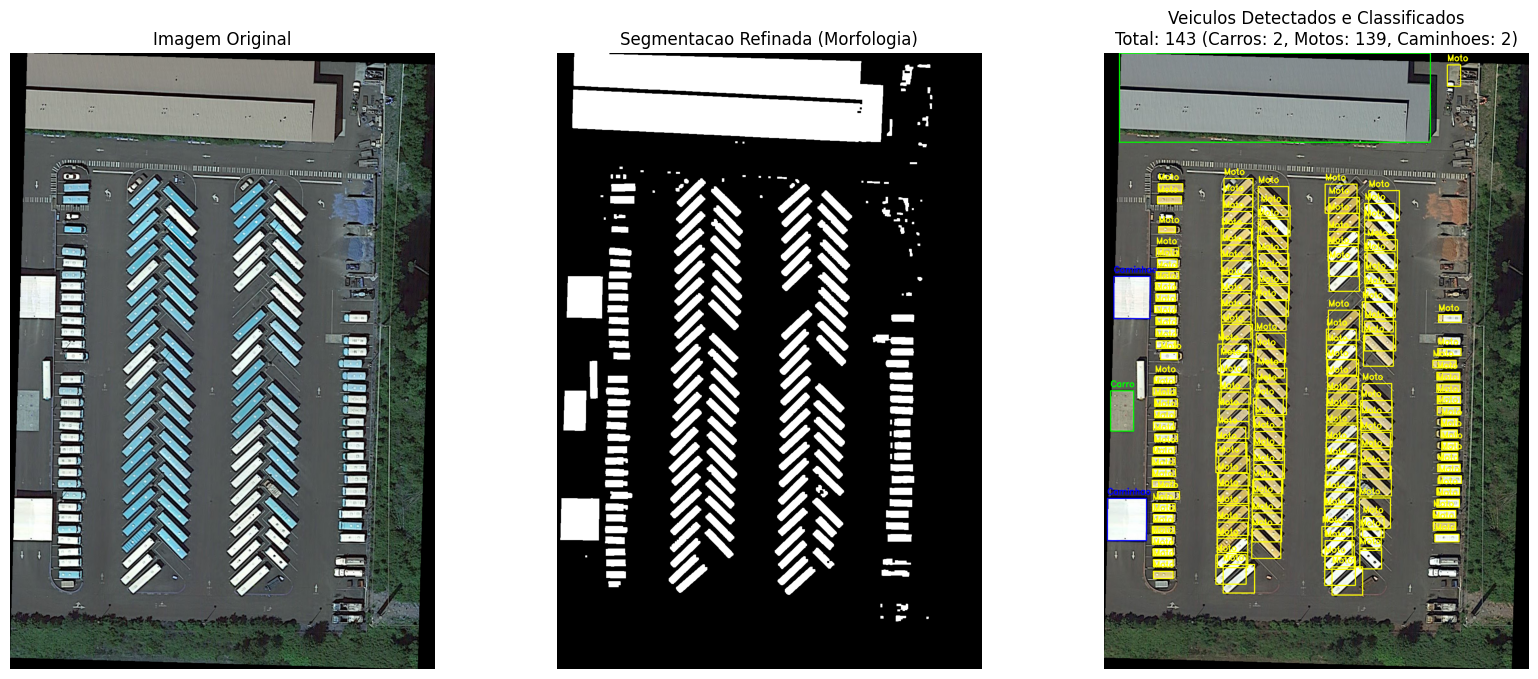

RESULTADO: Total de veiculos detectados: 143
RESULTADO: Carros: 2
RESULTADO: Motos: 139
RESULTADO: Caminhoes: 2


In [9]:
count_and_classify_vehicles(IMAGE_PATH)

In [1]:
import cv2
import numpy as np

# Funcao de retorno (callback) vazia, necessaria para a criacao dos trackbars do OpenCV.
def nothing(x):
    pass

# --- CRIACAO DO PAINEL DE CONTROLE ---
# Criamos uma janela chamada 'Painel de Afinacao' que contera todos os sliders.
cv2.namedWindow('Painel de Afinacao')
print("INFO: Ajuste os sliders e pressione 'q' para sair.")

# --- Sliders para a etapa de PRE-PROCESSAMENTO MORFOLOGICO ---
# Estes sliders controlam a remocao de ruidos e a uniao de regioes.
cv2.createTrackbar('Tamanho Kernel', 'Painel de Afinacao', 5, 15, nothing)
cv2.createTrackbar('Iter Abertura', 'Painel de Afinacao', 1, 5, nothing)
cv2.createTrackbar('Iter Fechamento', 'Painel de Afinacao', 1, 5, nothing)

# --- Sliders para a etapa de FILTRAGEM E CLASSIFICACAO ---
# Estes sliders definem os limiares de area e proporcao para classificar os veiculos.
cv2.createTrackbar('Area Min (Ruido)', 'Painel de Afinacao', 300, 2000, nothing)
cv2.createTrackbar('Area Moto/Carro', 'Painel de Afinacao', 1500, 10000, nothing)
cv2.createTrackbar('Area Carro/Cam.', 'Painel de Afinacao', 12000, 30000, nothing)
# Para a proporcao, o valor do slider e multiplicado por 100 para permitir o ajuste de casas decimais.
cv2.createTrackbar('Prop. Moto (Max)', 'Painel de Afinacao', 110, 200, nothing)      # Ex: 110 -> 1.10
cv2.createTrackbar('Prop. Caminhao (Min)', 'Painel de Afinacao', 250, 500, nothing) # Ex: 250 -> 2.50


def parameter_tuner(image_path):
    """
    Funcao principal que carrega uma imagem e permite o ajuste interativo
    de parametros para segmentacao e classificacao de veiculos usando
    criterios de area e proporcao (aspect ratio).
    """
    original_image = cv2.imread(image_path)
    # Verifica se a imagem foi carregada corretamente.
    if original_image is None:
        print(f"ERRO: Nao foi possivel carregar a imagem em {image_path}")
        return

    # Converte a imagem para escala de cinza, um pre-requisito para o limiar de Otsu.
    gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
    
    # Aplica o limiar de Otsu para binarizar a imagem automaticamente.
    ret, otsu_threshold = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Loop principal para atualizacao em tempo real.
    while True:
        # --- Captura os valores atuais dos sliders do painel de afinacao ---
        kernel_size = cv2.getTrackbarPos('Tamanho Kernel', 'Painel de Afinacao')
        opening_iterations = cv2.getTrackbarPos('Iter Abertura', 'Painel de Afinacao')
        closing_iterations = cv2.getTrackbarPos('Iter Fechamento', 'Painel de Afinacao')
        
        min_noise_area = cv2.getTrackbarPos('Area Min (Ruido)', 'Painel de Afinacao')
        area_threshold_moto_car = cv2.getTrackbarPos('Area Moto/Carro', 'Painel de Afinacao')
        area_threshold_car_truck = cv2.getTrackbarPos('Area Carro/Cam.', 'Painel de Afinacao')

        # Converte os valores inteiros dos sliders de proporcao para float.
        max_proportion_moto = cv2.getTrackbarPos('Prop. Moto (Max)', 'Painel de Afinacao') / 100.0
        min_proportion_truck = cv2.getTrackbarPos('Prop. Caminhao (Min)', 'Painel de Afinacao') / 100.0

        # --- Etapa de Processamento Morfologico ---
        # Garante que o tamanho do kernel seja sempre impar.
        if kernel_size % 2 == 0: kernel_size += 1
        # Garante que as iteracoes sejam no minimo 1.
        if opening_iterations == 0: opening_iterations = 1
        if closing_iterations == 0: closing_iterations = 1
        
        # Define o elemento estruturante (kernel) para as operacoes morfologicas.
        kernel = np.ones((kernel_size, kernel_size), np.uint8)
        
        # Operacao de Abertura: remove pequenos ruidos (pixels brancos isolados).
        opening = cv2.morphologyEx(otsu_threshold, cv2.MORPH_OPEN, kernel, iterations=opening_iterations)
        # Operacao de Fechamento: preenche pequenos buracos nos objetos (pixels pretos isolados).
        closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=closing_iterations)
        segmented_mask = closing

        # Encontra os contornos dos objetos na mascara segmentada.
        contours, _ = cv2.findContours(segmented_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Cria uma copia da imagem original para desenhar os resultados.
        display_image = original_image.copy()
        car_count, motorcycle_count, truck_count, unknown_count = 0, 0, 0, 0
        
        # --- Etapa de Classificacao dos Contornos ---
        for contour in contours:
            area = cv2.contourArea(contour)

            # 1. Filtro inicial de ruido: ignora contornos com area muito pequena.
            if area < min_noise_area:
                continue

            # Calcula o retangulo envolvente para obter as dimensoes (largura, altura).
            x, y, w, h = cv2.boundingRect(contour)
            
            # Calcula a proporcao (aspect ratio), com seguranca para evitar divisao por zero.
            aspect_ratio = float(w) / h if h > 0 else 0
            
            # Define valores padrao para o objeto detectado.
            object_type, color = 'Desconhecido', (0, 0, 255) # Vermelho para desconhecido

            # 2. Logica de decisao baseada em AREA e PROPORCAO.
            # E uma MOTO? (Area pequena E proporcao "vertical", ou seja, menor que um limiar).
            if area < area_threshold_moto_car and aspect_ratio < max_proportion_moto:
                object_type, motorcycle_count, color = "Moto", motorcycle_count + 1, (0, 255, 255) # Amarelo
            
            # E um CAMINHAO? (Area grande E proporcao "horizontal", ou seja, maior que um limiar).
            elif area > area_threshold_car_truck and aspect_ratio > min_proportion_truck:
                object_type, truck_count, color = "Caminhao", truck_count + 1, (255, 0, 0) # Azul
            
            # E um CARRO? (Area intermediaria e nao se encaixa nos criterios anteriores).
            elif area_threshold_moto_car < area < area_threshold_car_truck:
                object_type, car_count, color = "Carro", car_count + 1, (0, 255, 0) # Verde
            
            # Se nao foi classificado, mas passou pelo filtro de ruido, e contabilizado como desconhecido.
            else:
                unknown_count += 1
            
            # Desenha o retangulo e o texto de classificacao na imagem de exibicao.
            cv2.rectangle(display_image, (x, y), (x + w, y + h), color, 2)
            cv2.putText(display_image, f"{object_type} A:{int(area)} P:{aspect_ratio:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # --- Exibe os resultados na tela ---
        total = car_count + motorcycle_count + truck_count
        info_text = f"Total:{total} (C:{car_count} M:{motorcycle_count} T:{truck_count} D:{unknown_count})"
        cv2.putText(display_image, info_text, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        
        # Mostra as janelas com a mascara e o resultado final.
        cv2.imshow('Imagem Segmentada', segmented_mask)
        cv2.imshow('Deteccoes Inteligentes', display_image)

        # Aguarda a tecla 'q' ser pressionada para sair do loop.
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Libera os recursos e fecha todas as janelas do OpenCV.
    cv2.destroyAllWindows()
    
    # Imprime os parametros finais que foram ajustados, para uso posterior.
    print("\n--- Parâmetros Finais (Classificação Inteligente) ---")
    print(f"Area Minima (Ruido): {min_noise_area}")
    print(f"Limiar de Area Moto/Carro: {area_threshold_moto_car}")
    print(f"Limiar de Area Carro/Caminhao: {area_threshold_car_truck}")
    print(f"Proporcao Maxima da Moto: {max_proportion_moto}")
    print(f"Proporcao Minima do Caminhao: {min_proportion_truck}")

INFO: Ajuste os sliders e pressione 'q' para sair.


In [ ]:
if __name__ == '__main__':
    parameter_tuner(IMAGE_PATH)

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Painel de Afinacao' in function 'cvGetTrackbarPos'


: 